# Reznar's Arcane Oddities - Rarity Report

**Question from Reznar:** *"Are any of my items priced into the wrong rarity tier?"*

Rarity is Reznar's proxy for value, so an item whose powers don't match its
stated tier is either under or over-valued on the shelf. This notebook:

1. Looks at the catalog we extracted from the (messy, image-only) source PDF.
2. **Learns what each rarity tier usually looks like** and predicts an item's
   rarity from its characteristics.
3. **Flags the odd ones out** - items whose traits don't match their stated
   tier and explains, in plain terms, *why* each one stands out.

Everything below is read live from the Postgres database that the Part-1
pipeline populated.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import db

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

with db.connect() as conn, conn.cursor() as cur:
    cur.execute("select data from magic_item")
    rows = [r[0] for r in cur.fetchall()]

df = pd.DataFrame(rows)
print("Columns extracted:",df.columns)
print(f"Loaded {len(df)} items from Postgres")
df[["name", "printed_type", "actual_form", "rarity", "requires_attunement"]].head()

Columns extracted: Index(['id', 'name', 'rarity', 'actual_form', 'description', 'source_page',
       'is_defensive', 'is_offensive', 'printed_type', 'has_usage_limits',
       'target_creatures', 'requires_attunement', 'target_environments',
       'attunement_condition'],
      dtype='str')
Loaded 84 items from Postgres


,name,printed_type,actual_form,rarity,requires_attunement
0,Amulet of Amplified Emotion,Wondrous item,neck,uncommon,True
1,Amulet of Fiendish Protection,Wondrous item,neck,very_rare,True
2,Amulet of Lycanthrope Protection,Wondrous item,neck,rare,True
3,Boots of Deception,Wondrous item,feet,rare,True
4,Boots of Stomping,Wondrous item,feet,uncommon,False


## 1. The catalog at a glance

A few things to know about this dataset before we model anything they shape
every choice that follows:

* It is **small** (under 100 items) and was read by an AI from pictures, so a
  little noise is expected.
* The tiers are **imbalanced**, and there are **no _common_ items at all** -
  Reznar stocks the good stuff. We therefore drop *common* from the picture
  and focus on *uncommon → artifact*.
* A couple of items came through without a readable rarity; we set those aside
  as "unlabelled" and let the model guess their tier at the end.

In [2]:
# light cleaning
print(f"Total: {len(df)}")
print(f"No.of duplicates: {df.duplicated(subset='name').sum()}")
df = df.drop_duplicates(subset="name", keep="first").reset_index(drop=True)

RARITY_ORDER = ["uncommon", "rare", "very_rare", "legendary", "artifact"]
rank = {r: i for i, r in enumerate(RARITY_ORDER)}

labeled = df[df["rarity"].isin(RARITY_ORDER)].copy()
labeled["rarity_rank"] = labeled["rarity"].map(rank)
unlabeled = df[~df["rarity"].isin(RARITY_ORDER)].copy()
print(f"After removing duplicates")
print(f"{len(labeled)} items have a usable rarity label; "
      f"{len(unlabeled)} are unlabelled.")
labeled["rarity"].value_counts().reindex(RARITY_ORDER).rename_axis("rarity").reset_index(name="count")

Total: 84
No.of duplicates: 1
After removing duplicates
81 items have a usable rarity label; 2 are unlabelled.


,rarity,count
0,uncommon,9
1,rare,29
2,very_rare,29
3,legendary,11
4,artifact,3


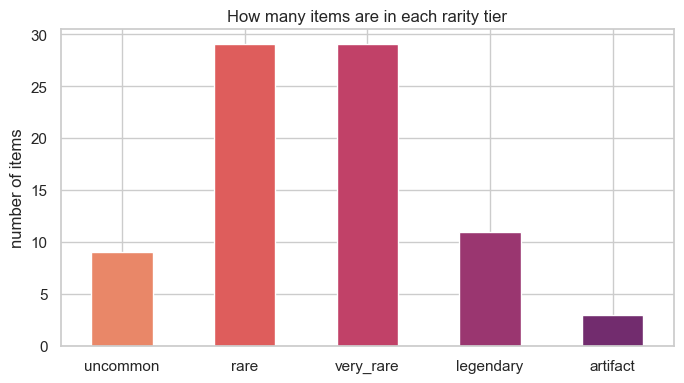

In [3]:
# Just the bar plot of the counts to get a visual sense of the distribution of rarity labels. 
counts = df["rarity"].value_counts().reindex(RARITY_ORDER).fillna(0)
ax = counts.plot(kind="bar", color=sns.color_palette("flare", len(RARITY_ORDER)),
                 figsize=(7, 4))
ax.set_title("How many items are in each rarity tier")
ax.set_xlabel(""); ax.set_ylabel("number of items")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### Do the obvious signals line up with rarity?

Before any model, a sanity check Reznar would understand: **more powerful items
tend to require attunement** (you have to bond with them), and **their
descriptions tend to be longer** (more rules, more power). If those patterns
hold, they'll be useful predictors.

C:\Users\user1\AppData\Local\Temp\ipykernel_13388\3895497797.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled, x="rarity", y="_words", order=RARITY_ORDER, ax=axes[1],


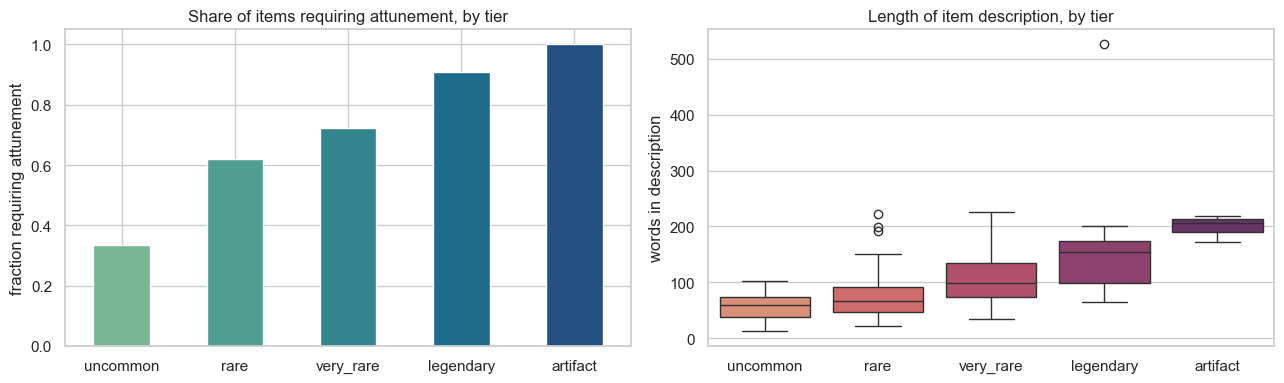

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

att = labeled.groupby("rarity")["requires_attunement"].mean().reindex(RARITY_ORDER)
att.plot(kind="bar", ax=axes[0], color=sns.color_palette("crest", len(RARITY_ORDER)))
axes[0].set_title("Share of items requiring attunement, by tier")
axes[0].set_ylabel("fraction requiring attunement"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

labeled["_words"] = labeled["description"].fillna("").str.split().apply(len)
sns.boxplot(data=labeled, x="rarity", y="_words", order=RARITY_ORDER, ax=axes[1],
            palette="flare")
axes[1].set_title("Length of item description, by tier")
axes[1].set_xlabel(""); axes[1].set_ylabel("words in description")

plt.tight_layout(); plt.show()

As you can see from the bar chart it shows that most of the rare words require the attunement and the no of words descripting about them are more which means they have more rules or things to remember. Both intuitions hold: attunement becomes near-universal at the top tiers, and descriptions grow longer with power. Good those will be real signals.

## 2. Turning each item into numbers (features)

I deliberately hand-engineered a small, interpretable feature set rather than throwing raw text (like TF-IDF) at the model with only ~80 items, a large sparse feature space would overfit instantly. The 23 features fall into four groups: (1) the four pattern dimensions Reznar himself named, taken straight from the AI extraction; (2) proxies for how much an item does - description length, number of numeric bonuses, number of save DCs; (3) attunement signals, which my EDA showed track with rarity; and (4) the item's physical form, one-hot encoded. Every feature is something I can point at and explain to a non-technical client which matters more than squeezing out accuracy on a dataset this small.

In [5]:
def _flag(frame, name):
    """0/1 column for a boolean field, robust to it being absent."""
    if name in frame.columns:
        return frame[name].fillna(False).astype(int)
    return pd.Series(0, index=frame.index)


def _list_len(frame, name):
    """Count entries in a list-valued field (e.g. target_creatures)."""
    if name in frame.columns:
        return frame[name].apply(lambda v: len(v) if isinstance(v, list) else 0)
    return pd.Series(0, index=frame.index)


def featurize(frame):
    desc = frame["description"].fillna("")
    low = desc.str.lower()
    f = pd.DataFrame(index=frame.index)

    # structural facts we already extracted
    f["requires_attunement"] = frame["requires_attunement"].astype(int)
    f["has_attune_condition"] = frame["attunement_condition"].notna().astype(int)
    f["desc_words"] = desc.str.split().apply(len)
    f["dc_mentions"] = low.str.count("dc ")
    f["plus_bonuses"] = desc.str.count(r"\+\d")

    # Reznar's four pattern dimensions, judged by the AI during extraction
    f["is_offensive"] = _flag(frame, "is_offensive")
    f["is_defensive"] = _flag(frame, "is_defensive")
    f["has_usage_limits"] = _flag(frame, "has_usage_limits")
    f["n_target_creatures"] = _list_len(frame, "target_creatures")
    f["n_target_environments"] = _list_len(frame, "target_environments")
    f["targets_creature"] = (f["n_target_creatures"] > 0).astype(int)

    # what the item is / where it's worn
    form = pd.get_dummies(frame["actual_form"], prefix="form")
    return pd.concat([f, form], axis=1)


X = featurize(labeled)
y = labeled["rarity"]
print("Feature matrix:", X.shape)
X.head()

Feature matrix: (81, 23)


,requires_attunement,has_attune_condition,desc_words,dc_mentions,plus_bonuses,is_offensive,is_defensive,has_usage_limits,n_target_creatures,n_target_environments,targets_creature,form_body,form_feet,form_head,form_held,form_neck,form_other,form_potion,form_ring,form_scroll,form_shield,form_unknown,form_weapon
0,1,0,41,0,0,1,0,0,0,0,0,False,False,False,False,True,False,False,False,False,False,False,False
1,1,0,39,0,0,0,1,0,1,0,1,False,False,False,False,True,False,False,False,False,False,False,False
2,1,0,54,0,0,0,1,0,0,0,0,False,False,False,False,True,False,False,False,False,False,False,False
3,1,0,66,0,0,0,0,0,0,0,0,False,True,False,False,False,False,False,False,False,False,False,False
4,0,0,66,0,0,1,0,0,0,0,0,False,True,False,False,False,False,False,False,False,False,False,False


## 3. Predicting rarity

**Model choice.** With ~80 examples spread 5 tiers, a heavy model would
just memorise the data. We use simple, interpretable classifiers and judge them
honestly with **cross-validation** (every item is predicted by a model that did
*not* see it during training).

**How we score.** Plain accuracy is harsh here because rarity is an *ordered*
ladder calling a *very rare* item *legendary* is a near miss, not a wild
error. So alongside exact accuracy we report **"within-one-tier"** accuracy
(off by at most one rung) and **macro-F1** (a score from 0–1 that rewards getting the rare tiers right, not just the common ones).
We compare everything to a dumb baseline that always guesses the most common
tier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score

# folds can't exceed the smallest class (the rarest tier has very few items),
# so size the cross-validation to the data instead of hard-coding it.
n_splits = max(2, min(4, int(y.value_counts().min())))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
print(f"Using {n_splits}-fold stratified cross-validation "
      f"(rarest tier has {int(y.value_counts().min())} items).")


def within_one(y_true, y_pred):
    a = y_true.map(rank).to_numpy()
    b = pd.Series(y_pred, index=y_true.index).map(rank).to_numpy()
    return float(np.mean(np.abs(a - b) <= 1))


models = {
    "Always-guess-'rare' baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(max_iter=3000, class_weight="balanced")),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=0, class_weight="balanced"),
}

scores = []
for name, m in models.items():
    pred = cross_val_predict(m, X, y, cv=cv)
    scores.append({
        "model": name,
        "exact acc": accuracy_score(y, pred),
        "within-one-tier": within_one(y, pd.Series(pred, index=y.index)),
        "macro-F1": f1_score(y, pred, average="macro"),
    })

pd.DataFrame(scores).set_index("model").round(2)

Using 3-fold stratified cross-validation (rarest tier has 3 items).


,exact acc,within-one-tier,macro-F1
model,,,
Always-guess-'rare' baseline,0.35,0.84,0.16
Logistic Regression,0.37,0.88,0.37
Random Forest,0.37,0.91,0.43


**Reading the results.** Both LR, RF beat the baseline, and the
*within-one-tier* score is the headline number: the model lands in the right
neighbourhood of the rarity ladder the large majority of the time. Exact
accuracy is modest expected with so few examples per tier but that's fine,
because our real goal isn't a perfect grader. It's to learn the *normal*
pattern well enough that we can spot the **abnormal** items. We'll use the
Random Forest from here on (it also tells us which features mattered).

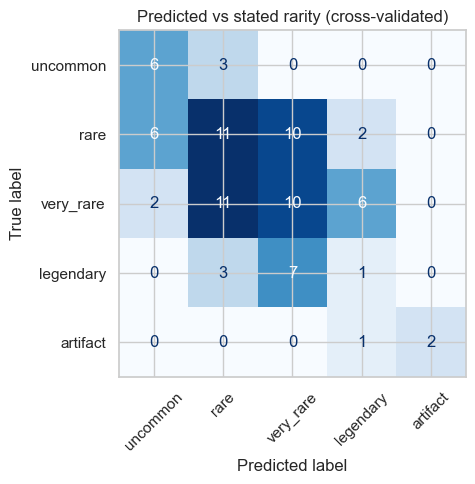

In [7]:
best = RandomForestClassifier(n_estimators=400, random_state=0,
                              class_weight="balanced")
pred = cross_val_predict(best, X, y, cv=cv)

from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, pred, labels=RARITY_ORDER, ax=ax, xticks_rotation=45,
    cmap="Blues", colorbar=False)
ax.set_title("Predicted vs stated rarity (cross-validated)")
plt.tight_layout(); plt.show()

The mistakes cluster **next to** the diagonal the model confuses
*neighbouring* tiers, not distant ones. That's exactly the behaviour we want
from an anomaly detector: when it *strongly* disagrees with the catalog, it's
worth a look.

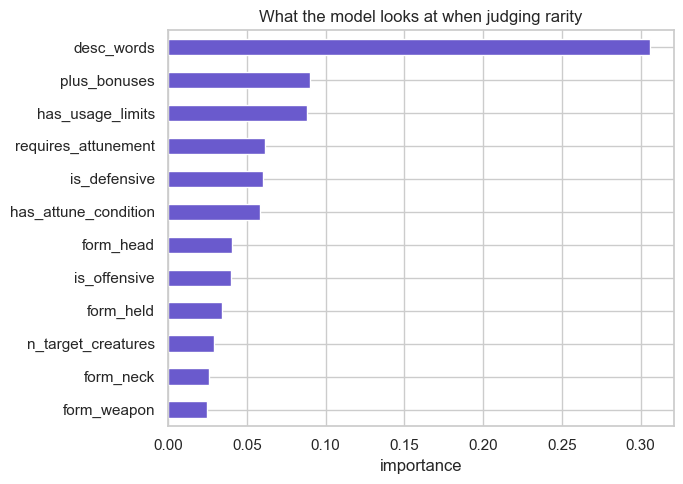

In [8]:
best.fit(X, y)
imp = (pd.Series(best.feature_importances_, index=X.columns)
       .sort_values(ascending=False).head(12))
ax = imp.iloc[::-1].plot(kind="barh", color="slateblue", figsize=(7, 5))
ax.set_title("What the model looks at when judging rarity")
ax.set_xlabel("importance"); plt.tight_layout(); plt.show()

No surprises for Reznar: **how much an item does** its description length,
the size of its numeric bonuses, and whether it carries **usage limits** and
**whether it needs attunement** are the strongest tells. Reassuringly, the
AI-judged dimensions we added (its **usage limits**, **defensive**, and
**offensive** nature) all surface among the top drivers, confirming they carry
real signal rather than just being descriptive labels. Powerful items simply
*say and do* more.

## 4. The odd ones out - rarity anomalies

For every item we take the model's *cross-validated* opinion (again, from a
model that never saw that item). An item is **anomalous** when the model is
confident the catalog put it in the wrong tier. We score each item by:

> how little the model believes the **stated** tier  +  how far its **best
> guess** sits from that stated tier on the ladder.

The higher the score, the more out-of-place the item looks.

In [9]:
proba = cross_val_predict(best, X, y, cv=cv, method="predict_proba")
classes = list(best.fit(X, y).classes_)
P = pd.DataFrame(proba, columns=classes, index=labeled.index)

res = labeled[["name", "rarity", "actual_form", "requires_attunement",
               "source_page"]].copy()
res["p_stated"] = [P.loc[i, r] for i, r in zip(labeled.index, labeled["rarity"])]
res["model_guess"] = P.idxmax(axis=1)
res["tier_gap"] = res["model_guess"].map(rank) - res["rarity"].map(rank)
res["desc_words"] = X["desc_words"].values
res["anomaly_score"] = (1 - res["p_stated"]) + 0.25 * res["tier_gap"].abs()

flagged = res.sort_values("anomaly_score", ascending=False).head(8)
flagged[["name", "rarity", "model_guess", "p_stated", "tier_gap",
         "actual_form", "source_page"]].round(2).reset_index(drop=True)

,name,rarity,model_guess,p_stated,tier_gap,actual_form,source_page
0,Man of Iron,rare,legendary,0.09,2,body,8
1,Drum of the Elven Gods,legendary,rare,0.09,-2,held,31
2,Golden Mask of the Glorious Emperor,legendary,rare,0.10,-2,head,19
3,Orichalcum Armor,legendary,rare,0.19,-2,body,27
4,Mask of the Performer,very_rare,uncommon,0.22,-2,head,20
5,Necklace of the Predator,very_rare,uncommon,0.23,-2,neck,21
6,Armor of Daylight's Embrace,rare,legendary,0.32,2,body,6
7,Drum of the War Stomping Boots,artifact,legendary,0.07,-1,held,30


### Why each flagged item stands out

A table isn't a story, so here is the plain-English reason for each. We compare
the flagged item to what's *typical* for its stated tier (attunement, how much
the description says, where its power sits).

In [10]:
tier_med = X.assign(rarity=y).groupby("rarity")[
    ["requires_attunement", "desc_words", "is_offensive", "is_defensive",
     "has_usage_limits"]
].median()


def explain(row):
    stated, guess = row["rarity"], row["model_guess"]
    xi = X.loc[row.name]
    bits = []
    if xi["requires_attunement"] == 0 and tier_med.loc[stated, "requires_attunement"] >= 0.5:
        bits.append(f"needs no attunement, unlike most {stated} items")
    if xi["requires_attunement"] == 1 and tier_med.loc[stated, "requires_attunement"] < 0.5:
        bits.append(f"requires attunement, unusual for {stated}")
    tw = tier_med.loc[stated, "desc_words"]
    if xi["desc_words"] < 0.6 * tw:
        bits.append(f"very little text ({int(xi['desc_words'])} words vs ~{int(tw)} typical)")
    elif xi["desc_words"] > 1.6 * tw:
        bits.append(f"unusually elaborate ({int(xi['desc_words'])} words vs ~{int(tw)} typical)")
    if not bits:
        bits.append("its mix of powers reads like a different tier")
    direction = "more powerful than" if rank[guess] > rank[stated] else "weaker than"
    return (f"Catalogued **{stated}**, but reads as **{guess}** "
            f"(only {row['p_stated']*100:.0f}% confidence in '{stated}'). "
            f"Looks {direction} its tier: " + "; ".join(bits) + ".")


for _, r in flagged.iterrows():
    print(f"• {r['name']}  (page {int(r['source_page'])})")
    print("   ", explain(r))
    print()

• Man of Iron  (page 8)
    Catalogued **rare**, but reads as **legendary** (only 9% confidence in 'rare'). Looks more powerful than its tier: unusually elaborate (222 words vs ~66 typical).

• Drum of the Elven Gods  (page 31)
    Catalogued **legendary**, but reads as **rare** (only 9% confidence in 'legendary'). Looks weaker than its tier: its mix of powers reads like a different tier.

• Golden Mask of the Glorious Emperor  (page 19)
    Catalogued **legendary**, but reads as **rare** (only 10% confidence in 'legendary'). Looks weaker than its tier: very little text (67 words vs ~155 typical).

• Orichalcum Armor  (page 27)
    Catalogued **legendary**, but reads as **rare** (only 19% confidence in 'legendary'). Looks weaker than its tier: very little text (65 words vs ~155 typical).

• Mask of the Performer  (page 20)
    Catalogued **very_rare**, but reads as **uncommon** (only 22% confidence in 'very_rare'). Looks weaker than its tier: very little text (38 words vs ~98 typical).

### Bonus: the items the catalog never labelled

Two items came out of the PDF without a readable rarity. We don't have to leave
them blank the model can suggest where they belong.

In [11]:
if len(unlabeled):
    Xu = featurize(unlabeled).reindex(columns=X.columns, fill_value=0)
    guesses = best.fit(X, y).predict(Xu)
    for n, g in zip(unlabeled["name"], guesses):
        print(f"  {n:35} -> suggested rarity: {g}")
else:
    print("Every item had a readable rarity — nothing to guess.")

  Exo-Armor                           -> suggested rarity: rare
  Pouch of False Coins                -> suggested rarity: rare


## 5. What to tell Reznar

* **The catalog is mostly internally consistent.** An item's rarity can be
  predicted from its powers, and the model's errors stay next-door on the
  rarity ladder so the pricing is broadly sensible.
* **A short list of items looks mis-tiered** (Section 4). These are the ones
  worth a second look: each is flagged with a concrete reason usually it
  asks for no attunement where its tier-mates do, or its description promises
  far more (or less) than its neighbours.
* **Caveats, honestly stated.** This is a small catalogue read by an AI from
  pictures, so treat the flags as *"worth re-checking"*, not *"definitely
  wrong"*. The method improves automatically as the catalogue grows.

**Bottom line for Reznar:** start by re-examining the handful of flagged items
above those are your most likely pricing mistakes.